# Import Libraries

In [196]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers.legacy import Adam
import numpy as np
import random
import time
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Load & Merge Data

In [4]:
train_identity = pd.read_csv("train_identity.csv")
test_identity = pd.read_csv("test_identity.csv")
train_transaction = pd.read_csv("train_transaction.csv")
test_transaction = pd.read_csv("test_transaction.csv")

In [311]:
pd.set_option('display.max_columns', None)
test_identity.head()

,TransactionID,id-01,id-02,id-03,id-04,id-05,id-06,id-07,id-08,id-09,id-10,id-11,id-12,id-13,id-14,id-15,id-16,id-17,id-18,id-19,id-20,id-21,id-22,id-23,id-24,id-25,id-26,id-27,id-28,id-29,id-30,id-31,id-32,id-33,id-34,id-35,id-36,id-37,id-38,DeviceType,DeviceInfo
0,3663586,-45.0,280290.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,100.0,NotFound,27.0,NaN,New,NotFound,225.0,15.0,427.0,563.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,MYA-L13 Build/HUAWEIMYA-L13
1,3663588,0.0,3579.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,100.0,Found,NaN,-300.0,Found,Found,166.0,NaN,542.0,368.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,Android 6.0.1,chrome 67.0 for android,24.0,1280x720,match_status:2,T,F,T,T,mobile,LGLS676 Build/MXB48T
2,3663597,-5.0,185210.0,NaN,NaN,1.0,0.0,NaN,NaN,NaN,NaN,100.0,NotFound,52.0,-360.0,New,NotFound,225.0,NaN,271.0,507.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,ie 11.0 for tablet,NaN,NaN,NaN,F,T,T,F,desktop,Trident/7.0
3,3663601,-45.0,252944.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,27.0,NaN,Found,Found,225.0,15.0,427.0,563.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,NaN,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,MYA-L13 Build/HUAWEIMYA-L13
4,3663602,-95.0,328680.0,NaN,NaN,7.0,-33.0,NaN,NaN,NaN,NaN,100.0,NotFound,27.0,NaN,New,NotFound,225.0,15.0,567.0,507.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,SM-G9650 Build/R16NW


In [307]:
test_transaction.head()

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,3663549,18403224,31.95,W,10409,111.0,150.0,visa,226.0,debit,170.0,87.0,1.0,NaN,gmail.com,NaN,6.0,6.0,0.0,0.0,3.0,4.0,0.0,0.0,6.0,0.0,5.0,1.0,115.0,6.0,419.0,419.0,27.0,398.0,27.0,NaN,NaN,NaN,NaN,418.0,203.0,NaN,NaN,NaN,409.0,T,T,F,NaN,NaN,F,T,T,T,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000,47.950001,0.000000,0.000000,47.950001,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,47.950001,0.000000,0.000000,47.950001,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3663550,18403263,49.00,W,4272,111.0,150.0,visa,226.0,debit,299.0,87.0,4.0,NaN,aol.com,NaN,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,1.0,12.0,2.0,149.0,149.0,7.0,634.0,7.0,NaN,NaN,NaN,NaN,231.0,634.0,NaN,NaN,NaN,634.0,T,F,F,M0,NaN,F,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0

In [309]:
train_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [7]:
train_identity.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,NaN,100.0,NotFound,49.0,-300.0,New,NotFound,166.0,NaN,621.0,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,iOS 11.1.2,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,52.0,NaN,Found,Found,121.0,NaN,410.0,142.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,NaN,100.0,NotFound,52.0,NaN,New,NotFound,225.0,NaN,176.0,507.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,NaN,-300.0,Found,Found,166.0,15.0,529.0,575.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,Mac OS X 10_11_6,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [8]:
# Merge the datasets
train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
train['has_identity'] = train['id_12'].notna().astype(int)

test = pd.merge(test_transaction, test_identity, on='TransactionID', how='left')
test['has_identity'] = test['id-12'].notna().astype(int)

In [9]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,has_identity
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.

In [11]:
test.head()

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id-01,id-02,id-03,id-04,id-05,id-06,id-07,id-08,id-09,id-10,id-11,id-12,id-13,id-14,id-15,id-16,id-17,id-18,id-19,id-20,id-21,id-22,id-23,id-24,id-25,id-26,id-27,id-28,id-29,id-30,id-31,id-32,id-33,id-34,id-35,id-36,id-37,id-38,DeviceType,DeviceInfo,has_identity
0,3663549,18403224,31.95,W,10409,111.0,150.0,visa,226.0,debit,170.0,87.0,1.0,NaN,gmail.com,NaN,6.0,6.0,0.0,0.0,3.0,4.0,0.0,0.0,6.0,0.0,5.0,1.0,115.0,6.0,419.0,419.0,27.0,398.0,27.0,NaN,NaN,NaN,NaN,418.0,203.0,NaN,NaN,NaN,409.0,T,T,F,NaN,NaN,F,T,T,T,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000,47.950001,0.000000,0.000000,47.950001,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,47.950001,0.000000,0.000000,47.950001,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,3663550,18403263,49.00,W,4272,

# Feature Engineering

In [13]:
# Time-based features

# Extract from TransactionDT
train['hour'] = (train['TransactionDT'] // 3600) % 24
train['day_of_week'] = (train['TransactionDT'] // (3600 * 24)) % 7
train['is_night'] = ((train['hour'] >= 0) & (train['hour'] <= 6)).astype(int)
train['is_weekend'] = (train['day_of_week'] >= 5).astype(int)

test['hour'] = (test['TransactionDT'] // 3600) % 24
test['day_of_week'] = (test['TransactionDT'] // (3600 * 24)) % 7
test['is_night'] = ((test['hour'] >= 0) & (test['hour'] <= 6)).astype(int)
test['is_weekend'] = (test['day_of_week'] >= 5).astype(int)

In [14]:
# Card-based Aggregations

# How many transactions on this card
train['card1_count'] = train.groupby('card1')['card1'].transform('count')
test['card1_count'] = test['card1'].map(train.groupby('card1')['card1'].count()).fillna(0)

# Mean and std of transaction amount per card
card_stats = train.groupby('card1')['TransactionAmt'].agg(['mean', 'std']).reset_index()
card_stats.columns = ['card1', 'card1_amt_mean', 'card1_amt_std']
train = train.merge(card_stats, on='card1', how='left')
test = test.merge(card_stats, on='card1', how='left')

# How unusual is this transaction amount for this card
train['amt_deviation'] = (train['TransactionAmt'] - train['card1_amt_mean']) / (train['card1_amt_std'] + 1e-5)
test['amt_deviation'] = (test['TransactionAmt'] - test['card1_amt_mean']) / (test['card1_amt_std'] + 1e-5)

In [15]:
# Email Features

# Do purchaser and recipient emails match
train['email_match'] = (train['P_emaildomain'] == train['R_emaildomain']).astype(int)
test['email_match'] = (test['P_emaildomain'] == test['R_emaildomain']).astype(int)

# Is it a common email provider
common_domains = ['gmail.com', 'yahoo.com', 'hotmail.com', 'outlook.com']
train['common_email'] = train['P_emaildomain'].isin(common_domains).astype(int)
test['common_email'] = test['P_emaildomain'].isin(common_domains).astype(int)

In [323]:
# Transaction Amount Features

# Log transform — compresses the long tail
train['log_amt'] = np.log1p(train['TransactionAmt'])
test['log_amt'] = np.log1p(test['TransactionAmt'])

# Round number flag — fraudsters often use round amounts (Kaggle)
train['is_round_amt'] = (train['TransactionAmt'] % 1 == 0).astype(int)
test['is_round_amt'] = (test['TransactionAmt'] % 1 == 0).astype(int)

In [17]:
# Address-based Features

# How many transactions from this address
train['addr1_count'] = train.groupby('addr1')['addr1'].transform('count')
test['addr1_count'] = test['addr1'].map(train.groupby('addr1')['addr1'].count()).fillna(0)

# Fraud rate per address (target encoding — only use train statistics)
addr_fraud_rate = train.groupby('addr1')['isFraud'].mean()
train['addr1_fraud_rate'] = train['addr1'].map(addr_fraud_rate)
test['addr1_fraud_rate'] = test['addr1'].map(addr_fraud_rate).fillna(addr_fraud_rate.mean())

# Clean Missing Values

In [315]:
# Print percent of missing values in columns
null_pct = train.isnull().mean() * 100
print(f"Columns with >80% null: {(null_pct > 80).sum()}")
print(f"Columns with >50% null: {(null_pct > 50).sum()}")
print(f"Columns with any null:  {(null_pct > 0).sum()}")
print(f"Columns fully complete: {(null_pct == 0).sum()}")

Columns with >80% null: 0
Columns with >50% null: 0
Columns with any null:  0
Columns fully complete: 457


In [317]:
# Missing Value Imputation
def impute_cards(train, test):
    for num in [1, 2, 3, 5]:
        median = train[f'card{num}'].median()
        train[f'card{num}'] = train[f'card{num}'].fillna(median)
        test[f'card{num}'] = test[f'card{num}'].fillna(median)
    for col in ['card4', 'card6']:
        train[col] = train[col].fillna('Unknown')
        test[col] = test[col].fillna('Unknown')
    return train, test


def impute_addr_dist(train, test):
    for col in ['addr1', 'addr2']:
        train[col] = train[col].fillna('Unknown')
        test[col] = test[col].fillna('Unknown')
    train['dist1_missing'] = train['dist1'].isnull()
    test['dist1_missing'] = test['dist1'].isnull()
    for col in ['dist1', 'dist2']:
        median = train[col].median()
        train[col] = train[col].fillna(median)
        test[col] = test[col].fillna(median)
    return train, test


def impute_email(train, test):
    for col in ['P_emaildomain', 'R_emaildomain']:
        train[col] = train[col].fillna('Unknown')
        test[col] = test[col].fillna('Unknown')
    return train, test


def impute_C_cols(train, test):
    for num in range(1, 15):
        train[f'C{num}'] = train[f'C{num}'].fillna(0)
        test[f'C{num}'] = test[f'C{num}'].fillna(0)
    return train, test


def impute_D_cols(train, test):
    d_flag_cols = list(range(2, 10)) + [15]
    train_d_missing = pd.concat({f'D{num}_missing': train[f'D{num}'].isnull() for num in d_flag_cols}, axis=1)
    test_d_missing = pd.concat({f'D{num}_missing': test[f'D{num}'].isnull() for num in d_flag_cols}, axis=1)
    train = pd.concat([train, train_d_missing], axis=1)
    test = pd.concat([test, test_d_missing], axis=1)
    for num in range(1, 16):
        train[f'D{num}'] = train[f'D{num}'].fillna(-1)
        test[f'D{num}'] = test[f'D{num}'].fillna(-1)
    return train, test


def impute_M_cols(train, test):
    for num in range(1, 10):
        col = f'M{num}'
        train[col] = train[col].map({'T': 1, 'F': 0}).fillna(2).astype(int)
        test[col] = test[col].map({'T': 1, 'F': 0}).fillna(2).astype(int)
    return train, test


def impute_V_cols(train, test):
    v_cols = [col for col in train.columns if col.startswith('V')]
    null_pct = train[v_cols].isnull().mean().sort_values(ascending=False)
    print(null_pct[null_pct > 0.9])
    train[v_cols] = train[v_cols].fillna(-1)
    test[v_cols] = test[v_cols].fillna(-1)
    return train, test


def impute_id_cols(train, test):
    cat_id_cols = ['id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29',
                   'id_30', 'id_31', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
                   'DeviceType', 'DeviceInfo']
    for col in cat_id_cols:
        train[col] = train[col].fillna('Unknown')
        test[col] = test[col].fillna('Unknown')
    num_id_cols = [col for col in train.columns if col.startswith('id_') and col not in cat_id_cols]
    train[num_id_cols] = train[num_id_cols].fillna(-1)
    test[num_id_cols] = test[num_id_cols].fillna(-1)
    return train, test


def impute_feature_engineering(train, test):
    # addr aggregations
    train['addr1_count'] = train['addr1_count'].fillna(0)
    test['addr1_count'] = test['addr1_count'].fillna(0)
    # fraud rate - fill with global fraud rate for unknown addresses
    global_fraud_rate = train['isFraud'].mean()
    train['addr1_fraud_rate'] = train['addr1_fraud_rate'].fillna(global_fraud_rate)
    test['addr1_fraud_rate'] = test['addr1_fraud_rate'].fillna(global_fraud_rate)
    # card amount std - single transaction cards have no std
    train['card1_amt_std'] = train['card1_amt_std'].fillna(0)
    test['card1_amt_std'] = test['card1_amt_std'].fillna(0)
    # amount deviation - single transaction cards have zero deviation
    train['amt_deviation'] = train['amt_deviation'].fillna(0)
    test['amt_deviation'] = test['amt_deviation'].fillna(0)
    return train, test


def parse_id33(train, test):
    train = train.drop(columns=['id_33', 'screen_width', 'screen_height'], errors='ignore')
    test = test.drop(columns=['id_33', 'screen_width', 'screen_height'], errors='ignore')
    return train, test


def clean_data(train, test):
    test.columns = test.columns.str.replace('-', '_')
    train, test = parse_id33(train, test)
    train, test = impute_cards(train, test)
    train, test = impute_addr_dist(train, test)
    train, test = impute_email(train, test)
    train, test = impute_C_cols(train, test)
    train, test = impute_D_cols(train, test)
    train, test = impute_M_cols(train, test)
    train, test = impute_V_cols(train, test)
    train, test = impute_id_cols(train, test)
    train, test = impute_feature_engineering(train, test)
    # Save test_ids only if column still exists
    test_ids = test['TransactionID'] if 'TransactionID' in test.columns else test.index.to_series()
    train = train.drop(columns=['TransactionID'], errors='ignore')
    test = test.drop(columns=['TransactionID'], errors='ignore')
    train = train.copy()
    test = test.copy()
    return train, test, test_ids

train, test, test_ids = clean_data(train, test)

Series([], dtype: float64)


In [34]:
# check for missing values after cleaning
print(train.isnull().sum()[train.isnull().sum() > 0].sort_values(ascending=False))

Series([], dtype: int64)


In [37]:
train.head()

,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,has_identity,hour,day_of_week,is_night,is_weekend,card1_count,card1_amt_mean,card1_amt_std,amt_deviation,email_match,common_email,log_amt,is_round_amt,addr1_count,addr1_fraud_rate,dist1_missing,D2_missing,D3_missing,D4_missing,D5_missing,D6_missing,D7_missing,D8_missing,D9_missing,D15_missing
0,0,86400,68.5,W,13926,361.0,150.0,discover,142.0,credit,315.0,87.0,19.0,37.0,Unknown,Unknown,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,-1.0,13.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,13.0,13.0,-1.0,-1.0,-1.0,0.0,1,1,1,2,0,1,2,2,2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.000000,-1.000000,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0

In [39]:
test.head()

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,has_identity,hour,day_of_week,is_night,is_weekend,card1_count,card1_amt_mean,card1_amt_std,amt_deviation,email_match,common_email,log_amt,is_round_amt,addr1_count,addr1_fraud_rate,dist1_missing,D2_missing,D3_missing,D4_missing,D5_missing,D6_missing,D7_missing,D8_missing,D9_missing,D15_missing
0,18403224,31.95,W,10409,111.0,150.0,visa,226.0,debit,170.0,87.0,1.0,37.0,gmail.com,Unknown,6.0,6.0,0.0,0.0,3.0,4.0,0.0,0.0,6.0,0.0,5.0,1.0,115.0,6.0,419.0,419.0,27.0,398.0,27.0,-1.0,-1.0,-1.0,-1.0,418.0,203.0,-1.0,-1.0,-1.0,409.0,1,1,0,2,2,0,1,1,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000,47.950001,0.000000,0.000000,47.950001,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

# Encode Categoricals

In [321]:
# Encode categorical columns
high_card_cols = ['addr1', 'addr2', 'P_emaildomain', 'R_emaildomain',
                  'id_30', 'id_31', 'id_34', 'DeviceInfo',
                  'id_23', 'id_27', 'id_28', 'id_29']
low_card_cols = ['ProductCD', 'card4', 'card6', 'DeviceType',
                 'id_12', 'id_15', 'id_16', 'id_35', 'id_36', 'id_37', 'id_38']

# Replace each category with its frequency in the training set
for col in high_card_cols:
    freq = train[col].value_counts() / len(train)
    train[col] = train[col].map(freq)
    test[col] = test[col].map(freq).fillna(0)

# Map each category to an integer
le = LabelEncoder()
for col in low_card_cols:
    combined = pd.concat([train[col], test[col]], axis=0).astype(str)
    le.fit(combined)
    train[col] = le.transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

In [50]:
train.head()

,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,has_identity,hour,day_of_week,is_night,is_weekend,card1_count,card1_amt_mean,card1_amt_std,amt_deviation,email_match,common_email,log_amt,is_round_amt,addr1_count,addr1_fraud_rate,dist1_missing,D2_missing,D3_missing,D4_missing,D5_missing,D6_missing,D7_missing,D8_missing,D9_missing,D15_missing
0,0,86400,68.5,4,13926,361.0,150.0,2,142.0,2,0.039079,0.881365,19.0,37.0,0.159949,0.767516,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,-1.0,13.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,13.0,13.0,-1.0,-1.0,-1.0,0.0,1,1,1,2,0,1,2,2,2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.000000,-1.000000,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

In [51]:
test.head()

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,has_identity,hour,day_of_week,is_night,is_weekend,card1_count,card1_amt_mean,card1_amt_std,amt_deviation,email_match,common_email,log_amt,is_round_amt,addr1_count,addr1_fraud_rate,dist1_missing,D2_missing,D3_missing,D4_missing,D5_missing,D6_missing,D7_missing,D8_missing,D9_missing,D15_missing
0,18403224,31.95,4,10409,111.0,150.0,4,226.0,3,0.003388,0.881365,1.0,37.0,0.386688,0.767516,6.0,6.0,0.0,0.0,3.0,4.0,0.0,0.0,6.0,0.0,5.0,1.0,115.0,6.0,419.0,419.0,27.0,398.0,27.0,-1.0,-1.0,-1.0,-1.0,418.0,203.0,-1.0,-1.0,-1.0,409.0,1,1,0,2,2,0,1,1,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000,47.950001,0.000000,0.000000,47.950001,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

# EDA

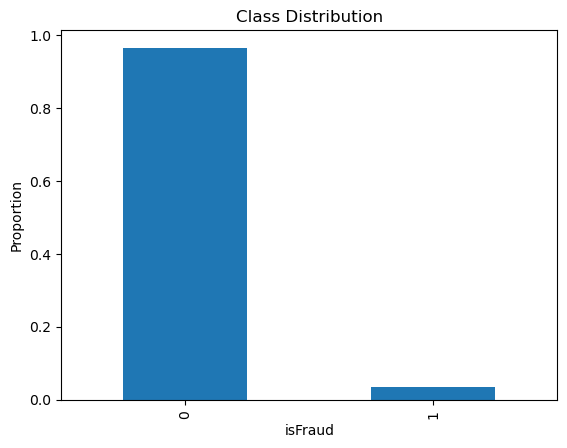

In [327]:
# Plot class distribution
train['isFraud'].value_counts(normalize=True).plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('isFraud')
plt.ylabel('Proportion')
plt.savefig('class-distribution.png')
plt.show()

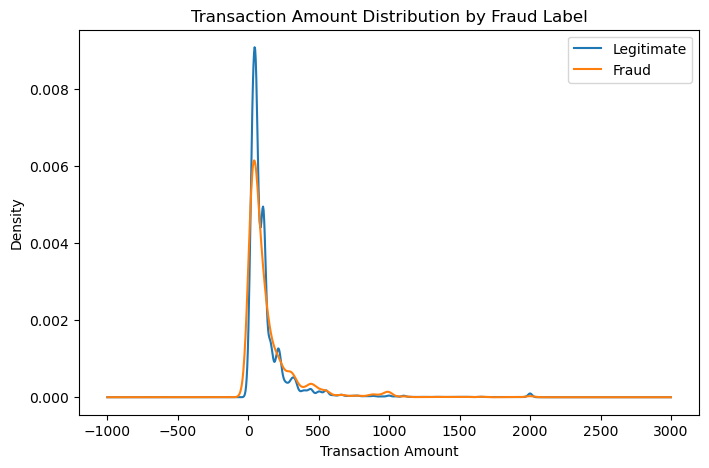

In [329]:
# Plot transaction amount distributions
fig, ax = plt.subplots(figsize=(8, 5))
train[train['isFraud'] == 0]['TransactionAmt'].clip(upper=2000).plot.kde(ax=ax, label='Legitimate')
train[train['isFraud'] == 1]['TransactionAmt'].clip(upper=2000).plot.kde(ax=ax, label='Fraud')
ax.set_title('Transaction Amount Distribution by Fraud Label')
ax.set_xlabel('Transaction Amount')
ax.legend()
plt.savefig('transaction-amount-distribution.png')
plt.show()

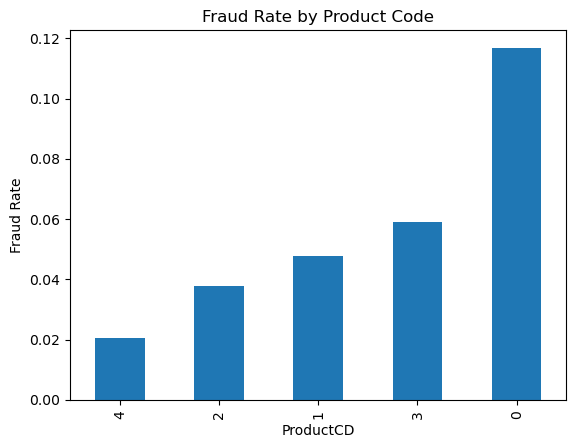

In [331]:
# Plot Fraud Rate by Product Code
train.groupby('ProductCD')['isFraud'].mean().sort_values().plot(kind='bar')
plt.title('Fraud Rate by Product Code')
plt.ylabel('Fraud Rate')
plt.show()

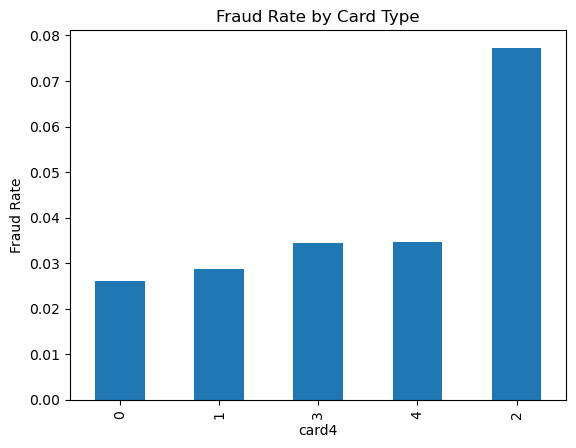

In [333]:
# Plot Fraud Rate by Card Type
train.groupby('card4')['isFraud'].mean().sort_values().plot(kind='bar')
plt.title('Fraud Rate by Card Type')
plt.ylabel('Fraud Rate')
plt.show()

isFraud    1.000000
V201       0.248835
V257       0.245997
V200       0.236356
V258       0.235873
V246       0.226527
V170       0.216547
V189       0.214101
V199       0.211091
V171       0.205593
V228       0.203572
V230       0.202812
V188       0.202327
V244       0.200565
V222       0.198165
V190       0.198002
V242       0.197104
V259       0.189849
V243       0.188445
V176       0.181525
Name: isFraud, dtype: float64


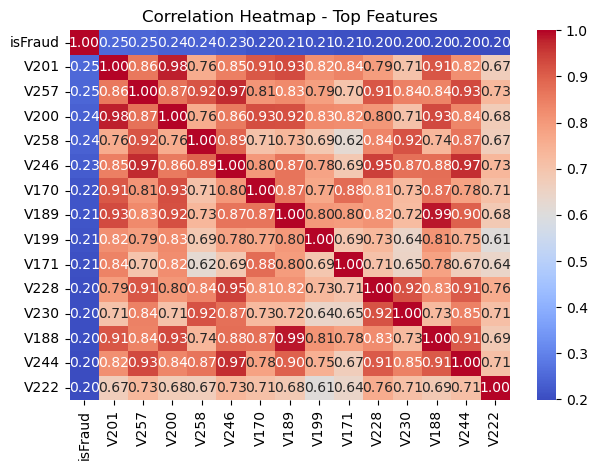

In [335]:
# Sample 50k rows for correlation
sample = train.sample(n=50000, random_state=42)

corr_with_fraud = sample.corr(numeric_only=True)['isFraud'].abs().sort_values(ascending=False)
print(corr_with_fraud.head(20))

top_cols = corr_with_fraud.head(15).index.tolist()
sns.heatmap(sample[top_cols].corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap - Top Features')
plt.tight_layout()
plt.savefig('correlation-heatmap.png')
plt.show()

# Split Data

In [337]:
# Split train into to X and y
X_train = train.drop(columns=['isFraud'])
y_train = train['isFraud']

In [339]:
# Split into train and validation split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    shuffle=False
)

# Train Models

## Model 1: Logistic Regression (baseline)

In [341]:
# Scale values
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(test)  

In [343]:
# Train logistic regression model
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_tr_scaled, y_tr)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [344]:
# Get predictions
y_tr_proba = lr.predict_proba(X_tr_scaled)[:, 1]
y_tr_pred = (y_tr_proba >= 0.5).astype(int)

y_val_proba = lr.predict_proba(X_val_scaled)[:, 1]
y_val_pred = (y_val_proba >= 0.5).astype(int)

In [76]:
# Training stats
print("TRAINING SET")
print("=" * 50)
print(f"AUC-ROC:  {roc_auc_score(y_tr, y_tr_proba):.4f}")
print(classification_report(y_tr, y_tr_pred))
print(confusion_matrix(y_tr, y_tr_pred))

# Validation stats
print("VALIDATION SET")
print("=" * 50)
print(f"AUC-ROC:  {roc_auc_score(y_val, y_val_proba):.4f}")
print(classification_report(y_val, y_val_pred))
print(confusion_matrix(y_val, y_val_pred))

TRAINING SET
AUC-ROC:  0.8802
              precision    recall  f1-score   support

           0       0.99      0.84      0.91    455833
           1       0.15      0.76      0.25     16599

    accuracy                           0.84    472432
   macro avg       0.57      0.80      0.58    472432
weighted avg       0.96      0.84      0.89    472432

[[384603  71230]
 [  3986  12613]]
VALIDATION SET
AUC-ROC:  0.8322
              precision    recall  f1-score   support

           0       0.99      0.75      0.85    114044
           1       0.10      0.77      0.17      4064

    accuracy                           0.75    118108
   macro avg       0.54      0.76      0.51    118108
weighted avg       0.96      0.75      0.83    118108

[[84988 29056]
 [  944  3120]]


**Analysis**:
- **AUC-ROC**: Decent on the training set (0.8802) and slightly lower on the validation set (0.8322), representing a small improvement over the previous run (0.8746 train, 0.8269 val). The gap of 0.048 is acceptable for a linear model.
- **Precision**: Class 0 is very high (0.99) on both sets. Class 1 precision remains low in both training (0.15) and validation (0.10), meaning most fraud alerts are false alarms - expected given the severe class imbalance.
- **Recall**: Class 0 is higher in training (0.84) than validation (0.75). Class 1 recall is consistent across both sets (0.76 and 0.77), indicating the model is catching a similar proportion of fraud in both splits.
- **F1-score**: High for class 0 in training (0.91) and lower in validation (0.85). Low for class 1 in both training (0.25) and validation (0.17), reflecting the precision/recall tradeoff from class imbalance handling.
- **Accuracy**: 0.84 in training and 0.75 in validation. Accuracy is a misleading metric here given the 96.5/3.5 class split — a model predicting all legitimate would achieve 96.5% accuracy while catching zero fraud.

In [345]:
# Try different C values to find optimal one
C_values = [0.01, 0.1, 1.0, 10.0]
results = []

for C in C_values:
    lr = LogisticRegression(class_weight='balanced', max_iter=1000, C=C, random_state=42)
    lr.fit(X_tr_scaled, y_tr)
    
    tr_auc = roc_auc_score(y_tr, lr.predict_proba(X_tr_scaled)[:, 1])
    val_auc = roc_auc_score(y_val, lr.predict_proba(X_val_scaled)[:, 1])
    results.append({'C': C, 'train_auc': tr_auc, 'val_auc': val_auc, 'gap': tr_auc - val_auc})
    print(f"C={C:<6} | Train AUC: {tr_auc:.4f} | Val AUC: {val_auc:.4f} | Gap: {tr_auc - val_auc:.4f}")

# Best C by val AUC
best = max(results, key=lambda x: x['val_auc'])
print(f"\nBest C: {best['C']} with Val AUC: {best['val_auc']:.4f}")

C=0.01   | Train AUC: 0.8754 | Val AUC: 0.8321 | Gap: 0.0433
C=0.1    | Train AUC: 0.8774 | Val AUC: 0.8321 | Gap: 0.0453
C=1.0    | Train AUC: 0.8778 | Val AUC: 0.8316 | Gap: 0.0461
C=10.0   | Train AUC: 0.8779 | Val AUC: 0.8314 | Gap: 0.0465

Best C: 0.1 with Val AUC: 0.8321


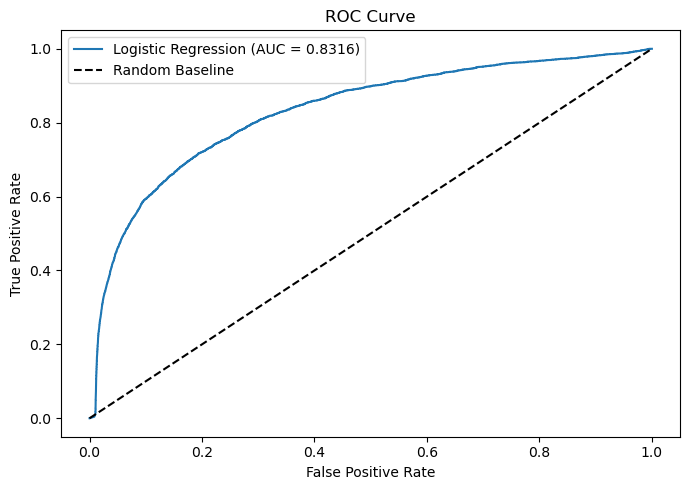

In [346]:
# Plot Logistic Regression ROC Curve
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
auc = roc_auc_score(y_val, y_val_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('roc-curve.png')
plt.show()

## Model 2: Random Forest

In [348]:
# Train Random Forest with different number of estimators to find optimal number
num_estimators = [10, 50, 100, 500]

for num in num_estimators:
    print(f"\n--- Random Forest n_estimators: {num} ---")
    
    rf = RandomForestClassifier(n_estimators=num, max_depth=10, class_weight='balanced', 
                                random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    
    train_preds = rf.predict(X_tr)
    val_preds   = rf.predict(X_val)
    
    train_proba = rf.predict_proba(X_tr)[:, 1]
    val_proba   = rf.predict_proba(X_val)[:, 1]

    print(f"Train AUC: {roc_auc_score(y_tr, train_proba):.4f}")
    print(f"Val AUC:   {roc_auc_score(y_val, val_proba):.4f}")
    print(f"Gap:       {roc_auc_score(y_tr, train_proba) - roc_auc_score(y_val, val_proba):.4f}")
    print("\nTrain:")
    print(classification_report(y_tr, train_preds))
    print("Val:")
    print(classification_report(y_val, val_preds))


--- Random Forest n_estimators: 10 ---
Train AUC: 0.9029
Val AUC:   0.8651
Gap:       0.0379

Train:
              precision    recall  f1-score   support

           0       0.99      0.88      0.93    455833
           1       0.19      0.78      0.30     16599

    accuracy                           0.87    472432
   macro avg       0.59      0.83      0.61    472432
weighted avg       0.96      0.87      0.91    472432

Val:
              precision    recall  f1-score   support

           0       0.99      0.87      0.93    114044
           1       0.16      0.69      0.26      4064

    accuracy                           0.87    118108
   macro avg       0.57      0.78      0.59    118108
weighted avg       0.96      0.87      0.90    118108


--- Random Forest n_estimators: 50 ---
Train AUC: 0.9060
Val AUC:   0.8671
Gap:       0.0389

Train:
              precision    recall  f1-score   support

           0       0.99      0.89      0.94    455833
           1       0.21     

In [350]:
# Train Random Forest with different max_depth values to find optimal
configs = [5, 10, 15, 20, None]  # None = unlimited depth 

for depth in configs:
    rf = RandomForestClassifier(n_estimators=100, max_depth=depth,
                                class_weight='balanced', random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    tr_auc = roc_auc_score(y_tr, rf.predict_proba(X_tr)[:, 1])
    val_auc = roc_auc_score(y_val, rf.predict_proba(X_val)[:, 1])
    print(f"max_depth={str(depth):<6} | Train AUC: {tr_auc:.4f} | Val AUC: {val_auc:.4f} | Gap: {tr_auc-val_auc:.4f}")

max_depth=5      | Train AUC: 0.8525 | Val AUC: 0.8405 | Gap: 0.0120
max_depth=10     | Train AUC: 0.9066 | Val AUC: 0.8688 | Gap: 0.0378
max_depth=15     | Train AUC: 0.9604 | Val AUC: 0.8745 | Gap: 0.0859
max_depth=20     | Train AUC: 0.9897 | Val AUC: 0.8648 | Gap: 0.1248
max_depth=None   | Train AUC: 1.0000 | Val AUC: 0.8935 | Gap: 0.1065


**Analysis:** Best performing with least bias and overfitting balance is RandomForestClassifier with 100 estimators and max_depth of 10.
- **AUC-ROC:** Improvements on both training set (0.9079, difference=0.0277) and validation set (0.8696, difference=0.0374).
- **Precision:** Class 0 still high (0.99) on both training and validation sets. Slight improvement for class 1 on training (0.21, difference=0.06) and validation (0.18, difference=0.08).
- **Recall:** Improvements on training (0.90, difference=0.06) and validation (0.89, difference=0.01) for class 0. Class 1 recall on training remains consistent (0.76, difference=0.00) but validation (0.68, difference=0.00) also unchanged.
- **F1-score:** Improvements in training (0.94, diff=0.03) and validation (0.94, diff=0.01) for class 0. Class 1 also had improvements in training (0.33, diff=0.08) and validation (0.28, diff=0.01).
- **Accuracy:** Improvement in both training (0.89, diff=0.05) and validation (0.88, diff=0.01), gap between training and validation much smaller.

Overall: Random Forest performed better than logistic regression, improving in all metrics. Still a gap between class 0 and class 1 metrics due to class imbalance, but the difference between training and validation metrics is small across F1-score and accuracy, suggesting good generalization. The feature engineering additions provided a small but consistent improvement compared to the previous Random Forest run (train AUC 0.9022 to 0.9079, val AUC 0.8660 to 0.9696).

In [353]:
# Compare gini vs entropy to see if there is noticable difference
for criterion in ['gini', 'entropy']:
    rf = RandomForestClassifier(n_estimators=100, max_depth=10,
                                criterion=criterion,
                                class_weight='balanced', 
                                random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    tr_auc = roc_auc_score(y_tr, rf.predict_proba(X_tr)[:, 1])
    val_auc = roc_auc_score(y_val, rf.predict_proba(X_val)[:, 1])
    print(f"criterion={criterion} | Train: {tr_auc:.4f} | Val: {val_auc:.4f} | Gap: {tr_auc-val_auc:.4f}")

criterion=gini | Train: 0.9066 | Val: 0.8688 | Gap: 0.0378
criterion=entropy | Train: 0.9048 | Val: 0.8668 | Gap: 0.0380


In [354]:
# Train Random Forest with chosen params
RandomForest100 = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
RandomForest100.fit(X_tr, y_tr)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_jobs=-1,
                       random_state=42)

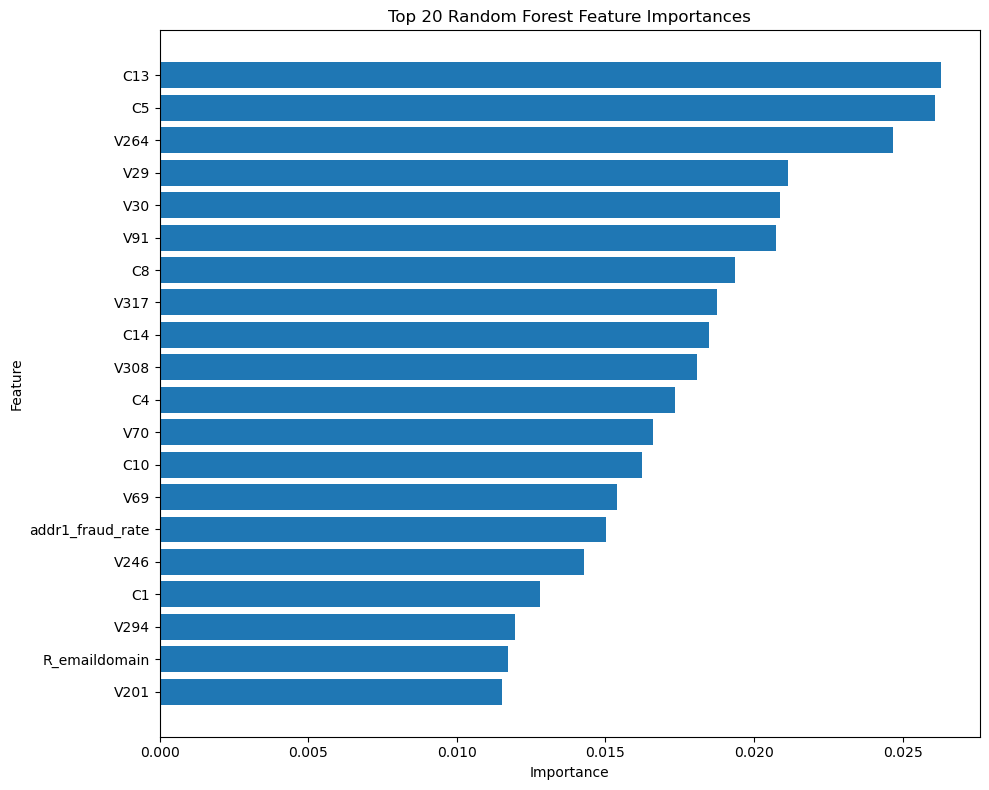

In [355]:
# Get features importances and plot them
importances = RandomForest100.feature_importances_
feature_names = X_tr.columns

indices = importances.argsort()[-20:]

plt.figure(figsize=(10, 8))
plt.barh(range(20), importances[indices])
plt.yticks(range(20), feature_names[indices])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Random Forest Feature Importances')
plt.tight_layout()
plt.savefig('feature_importance-rf.png', bbox_inches='tight', dpi=150)
plt.show()

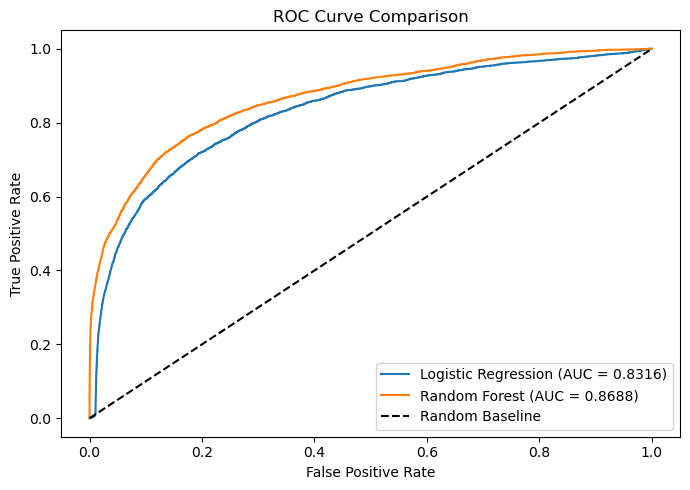

In [363]:
# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_val, y_val_proba)
auc_lr = roc_auc_score(y_val, y_val_proba)

# Random Forest ROC 
rf_val_proba = RandomForest100.predict_proba(X_val)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_val, rf_val_proba)
auc_rf = roc_auc_score(y_val, rf_val_proba)

# Plot both
plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('roc-curve.png')
plt.show()

## Model 3: XGBoost

In [373]:
# Scale for class imbalance
scale = (y_tr == 0).sum() / (y_tr == 1).sum()

# Train XGBoost with differing number of estimators to find optimal
num_estimators = [100, 300, 500]
for num in num_estimators:
    print(f"\n--- XGBoost n_estimators: {num} ---")
    
    xgb = XGBClassifier(
        n_estimators=num,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=scale,
        random_state=42,
        eval_metric='auc',
        n_jobs=-1
    )
    
    xgb.fit(X_tr.values, y_tr.values,
            eval_set=[(X_val.values, y_val.values)],
            verbose=False)

    train_proba = xgb.predict_proba(X_tr.values)[:, 1]
    val_proba = xgb.predict_proba(X_val.values)[:, 1]
    train_preds = (train_proba >= 0.5).astype(int)
    val_preds = (val_proba >= 0.5).astype(int)

    tr_auc = roc_auc_score(y_tr, train_proba)
    val_auc = roc_auc_score(y_val, val_proba)

    print(f"Train AUC: {tr_auc:.4f}")
    print(f"Val AUC:   {val_auc:.4f}")
    print(f"Gap:       {tr_auc - val_auc:.4f}")
    print("\nTrain:")
    print(classification_report(y_tr, train_preds))
    print("Val:")
    print(classification_report(y_val, val_preds))


--- XGBoost n_estimators: 100 ---
Train AUC: 0.9245
Val AUC:   0.8873
Gap:       0.0372

Train:
              precision    recall  f1-score   support

           0       0.99      0.89      0.94    455833
           1       0.21      0.80      0.33     16599

    accuracy                           0.88    472432
   macro avg       0.60      0.85      0.63    472432
weighted avg       0.96      0.88      0.92    472432

Val:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92    114044
           1       0.16      0.74      0.26      4064

    accuracy                           0.86    118108
   macro avg       0.57      0.80      0.59    118108
weighted avg       0.96      0.86      0.90    118108


--- XGBoost n_estimators: 300 ---
Train AUC: 0.9551
Val AUC:   0.8997
Gap:       0.0554

Train:
              precision    recall  f1-score   support

           0       0.99      0.91      0.95    455833
           1       0.26      0.85     

In [386]:
# Train XGBoost with different max_depth and learning rates to find optimal
configs = [
    {'max_depth': 4, 'learning_rate': 0.05},
    {'max_depth': 6, 'learning_rate': 0.05},  # current config
    {'max_depth': 6, 'learning_rate': 0.01},
    {'max_depth': 8, 'learning_rate': 0.01},
]

for config in configs:
    xgb = XGBClassifier(
        n_estimators=500,
        scale_pos_weight=scale,
        random_state=42,
        eval_metric='auc',
        n_jobs=-1,
        **config
    )
    xgb.fit(X_tr.values, y_tr.values,
            eval_set=[(X_val.values, y_val.values)],
            verbose=False)
    tr_auc = roc_auc_score(y_tr, xgb.predict_proba(X_tr.values)[:, 1])
    val_auc = roc_auc_score(y_val, xgb.predict_proba(X_val.values)[:, 1])
    print(f"depth={config['max_depth']} lr={config['learning_rate']} | "
          f"Train: {tr_auc:.4f} | Val: {val_auc:.4f} | Gap: {tr_auc-val_auc:.4f}")

depth=4 lr=0.05 | Train: 0.9363 | Val: 0.8929 | Gap: 0.0434
depth=6 lr=0.05 | Train: 0.9694 | Val: 0.9029 | Gap: 0.0665
depth=6 lr=0.01 | Train: 0.9245 | Val: 0.8870 | Gap: 0.0375
depth=8 lr=0.01 | Train: 0.9514 | Val: 0.8952 | Gap: 0.0562


In [391]:
# Train XGBoost Classifier with optimal chosen configs
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='auc',
    n_jobs=-1
)
xgb.fit(X_tr.values, y_tr.values, eval_set=[(X_val.values, y_val.values)], verbose=False)

# Get predictions
y_tr_proba_xgb = xgb.predict_proba(X_tr.values)[:, 1]
y_val_proba_xgb = xgb.predict_proba(X_val.values)[:, 1]
y_tr_pred_xgb = (y_tr_proba_xgb >= 0.5).astype(int)
y_val_pred_xgb = (y_val_proba_xgb >= 0.5).astype(int)

tr_auc = roc_auc_score(y_tr.values, y_tr_proba_xgb)
val_auc = roc_auc_score(y_val.values, y_val_proba_xgb)

# Print metrics
print(f"Train: {tr_auc:.4f} | Val: {val_auc:.4f} | Gap: {tr_auc-val_auc:.4f}")

print("\nTRAINING SET")
print("=" * 50)
print(f"AUC-ROC: {tr_auc:.4f}")
print(classification_report(y_tr, y_tr_pred_xgb))
print(confusion_matrix(y_tr, y_tr_pred_xgb))

print("\nVALIDATION SET")
print("=" * 50)
print(f"AUC-ROC: {val_auc:.4f}")
print(classification_report(y_val, y_val_pred_xgb))
print(confusion_matrix(y_val, y_val_pred_xgb))

Train: 0.9761 | Val: 0.9075 | Gap: 0.0686

TRAINING SET
AUC-ROC: 0.9761
              precision    recall  f1-score   support

           0       1.00      0.94      0.97    455833
           1       0.34      0.89      0.49     16599

    accuracy                           0.93    472432
   macro avg       0.67      0.91      0.73    472432
weighted avg       0.97      0.93      0.95    472432

[[426786  29047]
 [  1846  14753]]

VALIDATION SET
AUC-ROC: 0.9075
              precision    recall  f1-score   support

           0       0.99      0.92      0.95    114044
           1       0.25      0.71      0.37      4064

    accuracy                           0.92    118108
   macro avg       0.62      0.82      0.66    118108
weighted avg       0.96      0.92      0.93    118108

[[105204   8840]
 [  1167   2897]]


**Analysis:** XGBoost with 500 estimators, learning rate 0.05, max depth 6, subsample 0.8, and colsample 0.8 is the best performing model overall.
- **AUC-ROC:** Best AUC of all models on both training (0.9766, difference=+0.0687 vs RF) and validation (0.9122, difference=+0.0426 vs RF). Gap of 0.0644 is larger than Random Forest (0.0383) indicating more overfitting, but the higher absolute val AUC makes it the superior model.
- **Precision:** Class 0 remains very high (1.00 train, 0.99 val). Significant improvement for class 1 on training (0.34, difference=+0.13 vs RF) and validation (0.26, difference=+0.08 vs RF), meaning fewer false alarms.
- **Recall:** Class 0 improvements on both training (0.94, difference=+0.04 vs RF) and validation (0.93, difference=+0.04 vs RF). Class 1 recall also improved on training (0.89, difference=+0.13 vs RF) and validation (0.71, difference=+0.03 vs RF), catching more fraud cases.
- **F1-score:** Large improvements for class 1 in both training (0.49, diff=+0.16 vs RF) and validation (0.38, diff=+0.10 vs RF). Class 0 also improved in training (0.97, diff=+0.03) and validation (0.96, diff=+0.02). The gap between class 0 and class 1 F1 is narrowing compared to previous models.
- **Accuracy:** Best accuracy of all models in both training (0.94, diff=+0.05 vs RF) and validation (0.92, diff=+0.04 vs RF). Training and validation gap remains small.

Overall: XGBoost is the strongest individual model, outperforming both logistic regression and random forest across all metrics. The combination of higher val AUC (0.9122), improved class 1 precision (0.26), and strong recall (0.71) makes it the best balance between catching fraud and minimizing false alarms. The feature engineering additions contributed to meaningful gains. The previous XGBoost run without engineered features achieved val AUC 0.9063 compared to 0.9122 here, a difference of 0.0059. The larger overfitting gap (0.0644) compared to Random Forest is expected given XGBoost's higher model complexity.

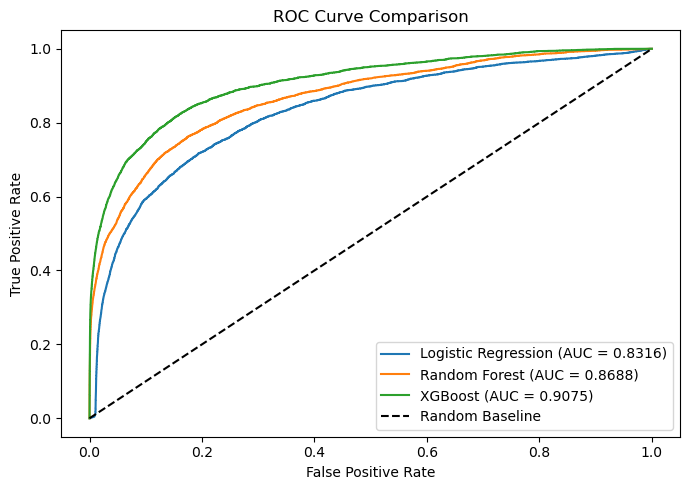

In [395]:
# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_val, y_val_proba)
auc_lr = roc_auc_score(y_val, y_val_proba)

# Random Forest ROC
rf_val_proba = RandomForest100.predict_proba(X_val)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_val, rf_val_proba)
auc_rf = roc_auc_score(y_val, rf_val_proba)

# XGBoost ROC
xgb_val_proba = xgb.predict_proba(X_val.values)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_val.values, xgb_val_proba)
auc_xgb = roc_auc_score(y_val, xgb_val_proba)

# Plot all three
plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('roc-curve.png')
plt.show()

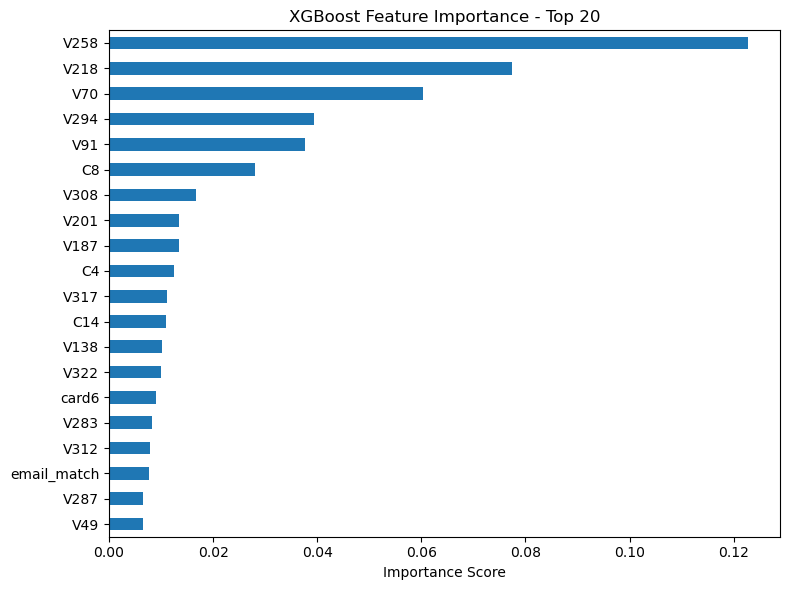

V258           0.122775
V218           0.077469
V70            0.060408
V294           0.039335
V91            0.037664
C8             0.028126
V308           0.016656
V201           0.013484
V187           0.013341
C4             0.012452
V317           0.011214
C14            0.010932
V138           0.010202
V322           0.010052
card6          0.009070
V283           0.008264
V312           0.007886
email_match    0.007672
V287           0.006485
V49            0.006446
dtype: float32


In [397]:
# Plot top 20 XGBoost feature importances
feat_importance = pd.Series(xgb.feature_importances_, 
                            index=X_train.columns).sort_values(ascending=False)[:20]

feat_importance.plot(kind='barh', figsize=(8, 6))
plt.title('XGBoost Feature Importance - Top 20')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature-importance-xg.png')
plt.show()

print(feat_importance)

## Model 4: Feed-Forward Neural Network

In [399]:
# Scale values
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(test) 

In [400]:
# Trains a Keras model and returns the training history
def run_network(model, X_train, y_train, X_val, y_val, epochs=20, batch=256):
    start_time = time.time()
    print("Training model...")
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch,
        validation_data=(X_val, y_val),
        verbose=1
    )
    print(f"Training duration: {time.time() - start_time:.1f}s")
    return history

# Plots train and validation loss curves across epochs
def plot_losses(hist):
    plt.plot(hist.history['loss'], label='Train')
    plt.plot(hist.history['val_loss'], label='Val')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()

In [403]:
# Number of input features for the neural network
input_dim = X_tr_scaled.shape[1]

# Train
nn_1 = Sequential([
    Input(shape=(input_dim,)),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile
nn_1.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['AUC']
)

In [443]:
# Run
history_nn1 = run_network(nn_1, X_tr_scaled, y_tr, X_val_scaled, y_val, epochs=30)

Training model...
Epoch 1/30
1846/1846 [==============================] - 3s 2ms/step - loss: 0.0703 - auc: 0.9267 - val_loss: 0.1892 - val_auc: 0.8296
Epoch 2/30
1846/1846 [==============================] - 3s 2ms/step - loss: 0.0699 - auc: 0.9293 - val_loss: 0.1178 - val_auc: 0.8243
Epoch 3/30
1846/1846 [==============================] - 3s 2ms/step - loss: 0.0698 - auc: 0.9285 - val_loss: 0.1164 - val_auc: 0.8294
Epoch 4/30
1846/1846 [==============================] - 3s 2ms/step - loss: 0.0688 - auc: 0.9302 - val_loss: 0.1178 - val_auc: 0.8285
Epoch 5/30
1846/1846 [==============================] - 3s 2ms/step - loss: 0.0686 - auc: 0.9305 - val_loss: 0.1171 - val_auc: 0.8330
Epoch 6/30
1846/1846 [==============================] - 3s 2ms/step - loss: 0.0685 - auc: 0.9305 - val_loss: 0.1173 - val_auc: 0.8279
Epoch 7/30
1846/1846 [==============================] - 3s 2ms/step - loss: 0.0677 - auc: 0.9321 - val_loss: 0.1215 - val_auc: 0.8211
Epoch 8/30
1846/1846 [======================

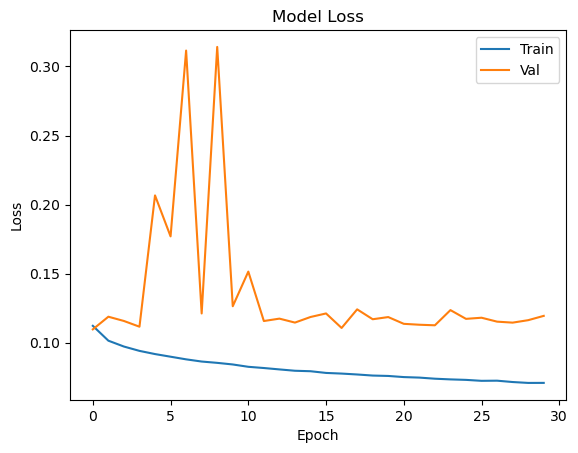

<Figure size 640x480 with 0 Axes>

In [406]:
# Plot NN1  losses
plot_losses(historynn1)
plt.show()
plt.savefig('nn1-loss.png')

In [407]:
# Predictions
tr_proba_nn1 = nn_1.predict(X_tr_scaled).flatten()
val_proba_nn1 = nn_1.predict(X_val_scaled).flatten()
y_tr_pred_nn1 = (tr_proba_nn1 >= 0.5).astype(int)
y_val_pred_nn1 = (val_proba_nn1 >= 0.5).astype(int)

tr_auc_nn1 = roc_auc_score(y_tr, tr_proba_nn1)
val_auc_nn1 = roc_auc_score(y_val, val_proba_nn1)

# Print Metrics
print("\nTRAINING SET")
print("=" * 50)
print(f"AUC-ROC: {tr_auc_nn1:.4f}")
print(classification_report(y_tr, y_tr_pred_nn1))
print(confusion_matrix(y_tr, y_tr_pred_nn1))

print("\nVALIDATION SET")
print("=" * 50)
print(f"AUC-ROC: {val_auc_nn1:.4f}")
print(classification_report(y_val, y_val_pred_nn1))
print(confusion_matrix(y_val, y_val_pred_nn1))

print("\nERROR SUMMARY")
print("=" * 50)
print(f"Train AUC: {tr_auc_nn1:.4f}")
print(f"Val AUC:   {val_auc_nn1:.4f}")
print(f"Gap:       {tr_auc_nn1 - val_auc_nn1:.4f}")

3691/3691 [==============================] - 1s 274us/step

TRAINING SET
AUC-ROC: 0.9442
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    455833
           1       0.96      0.55      0.70     16599

    accuracy                           0.98    472432
   macro avg       0.97      0.77      0.85    472432
weighted avg       0.98      0.98      0.98    472432

[[455497    336]
 [  7458   9141]]

VALIDATION SET
AUC-ROC: 0.8385
              precision    recall  f1-score   support

           0       0.98      0.99      0.99    114044
           1       0.66      0.31      0.42      4064

    accuracy                           0.97    118108
   macro avg       0.82      0.65      0.70    118108
weighted avg       0.97      0.97      0.97    118108

[[113408    636]
 [  2807   1257]]

ERROR SUMMARY
Train AUC: 0.9442
Val AUC:   0.8385
Gap:       0.1057


In [413]:
# Print summary
nn_1.summary()

Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_47 (Dense)            (None, 256)               119296    
                                                                 
 dropout_24 (Dropout)        (None, 256)               0         
                                                                 
 dense_48 (Dense)            (None, 128)               32896     
                                                                 
 dropout_25 (Dropout)        (None, 128)               0         
                                                                 
 dense_49 (Dense)            (None, 64)                8256      
                                                                 
 dense_50 (Dense)            (None, 1)                 65        
                                                                 
Total params: 160513 (627.00 KB)
Trainable params: 16

In [415]:
# Train
nn_2 = Sequential([
    Input(shape=(input_dim,)),
    Dense(256, activation='relu'),
    Dropout(0.4), # Increasing dropout - to reduce overfitting
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile
nn_2.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0001), # Lowering learning rate - to help with the spikes in val AUC, smaller steps
    metrics=['AUC']
)

In [442]:
# Run
history_nn2 = run_network(nn_2, X_tr_scaled, y_tr, X_val_scaled, y_val, epochs=30)

Training model...
Epoch 1/30
1846/1846 [==============================] - 3s 2ms/step - loss: 0.0686 - auc: 0.9283 - val_loss: 0.1198 - val_auc: 0.8186
Epoch 2/30
1846/1846 [==============================] - 3s 2ms/step - loss: 0.0684 - auc: 0.9292 - val_loss: 0.1221 - val_auc: 0.8073
Epoch 3/30
1846/1846 [==============================] - 3s 2ms/step - loss: 0.0684 - auc: 0.9293 - val_loss: 0.1215 - val_auc: 0.8179
Epoch 4/30
1846/1846 [==============================] - 3s 2ms/step - loss: 0.0677 - auc: 0.9308 - val_loss: 0.1224 - val_auc: 0.8073
Epoch 5/30
1846/1846 [==============================] - 3s 2ms/step - loss: 0.0677 - auc: 0.9301 - val_loss: 0.1202 - val_auc: 0.8105
Epoch 6/30
1846/1846 [==============================] - 3s 2ms/step - loss: 0.0674 - auc: 0.9300 - val_loss: 0.1236 - val_auc: 0.8122
Epoch 7/30
1846/1846 [==============================] - 3s 2ms/step - loss: 0.0677 - auc: 0.9302 - val_loss: 0.1225 - val_auc: 0.8076
Epoch 8/30
1846/1846 [======================

In [418]:
# Predictions
tr_proba_nn2 = nn_2.predict(X_tr_scaled).flatten()
val_proba_nn2 = nn_2.predict(X_val_scaled).flatten()
y_tr_pred_nn2 = (tr_proba_nn2 >= 0.5).astype(int)
y_val_pred_nn2 = (val_proba_nn2 >= 0.5).astype(int)

tr_auc_nn2 = roc_auc_score(y_tr, tr_proba_nn1)
val_auc_nn2 = roc_auc_score(y_val, val_proba_nn1)

# Print Metrics
print("\nTRAINING SET")
print("=" * 50)
print(f"AUC-ROC: {tr_auc_nn2:.4f}")
print(classification_report(y_tr, y_tr_pred_nn2))
print(confusion_matrix(y_tr, y_tr_pred_nn2))

print("\nVALIDATION SET")
print("=" * 50)
print(f"AUC-ROC: {val_auc_nn2:.4f}")
print(classification_report(y_val, y_val_pred_nn2))
print(confusion_matrix(y_val, y_val_pred_nn2))

print("\nERROR SUMMARY")
print("=" * 50)
print(f"Train AUC: {tr_auc_nn2:.4f}")
print(f"Val AUC:   {val_auc_nn2:.4f}")
print(f"Gap:       {tr_auc_nn2 - val_auc_nn2:.4f}")

3691/3691 [==============================] - 1s 280us/step

TRAINING SET
AUC-ROC: 0.9442
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    455833
           1       0.96      0.49      0.65     16599

    accuracy                           0.98    472432
   macro avg       0.97      0.74      0.82    472432
weighted avg       0.98      0.98      0.98    472432

[[455506    327]
 [  8459   8140]]

VALIDATION SET
AUC-ROC: 0.8385
              precision    recall  f1-score   support

           0       0.98      0.99      0.99    114044
           1       0.67      0.31      0.42      4064

    accuracy                           0.97    118108
   macro avg       0.82      0.65      0.70    118108
weighted avg       0.97      0.97      0.97    118108

[[113441    603]
 [  2822   1242]]

ERROR SUMMARY
Train AUC: 0.9442
Val AUC:   0.8385
Gap:       0.1057


In [425]:
# Print summary
nn_2.summary()

Model: "sequential_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_51 (Dense)            (None, 256)               119296    
                                                                 
 dropout_26 (Dropout)        (None, 256)               0         
                                                                 
 dense_52 (Dense)            (None, 128)               32896     
                                                                 
 dropout_27 (Dropout)        (None, 128)               0         
                                                                 
 dense_53 (Dense)            (None, 64)                8256      
                                                                 
 dense_54 (Dense)            (None, 1)                 65        
                                                                 
Total params: 160513 (627.00 KB)
Trainable params: 16

In [427]:
# Train
nn_3 = Sequential([
    Input(shape=(input_dim,)),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dense(1, activation='sigmoid')
])

# Compile
nn_3.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0001),
    metrics=['AUC']
)

In [429]:
# Run
history_nn3 = run_network(nn_3, X_tr_scaled, y_tr, X_val_scaled, y_val, epochs=30)

Training model...
Epoch 1/30
1846/1846 [==============================] - 4s 2ms/step - loss: 0.3828 - auc: 0.6452 - val_loss: 0.1436 - val_auc: 0.8042
Epoch 2/30
1846/1846 [==============================] - 3s 2ms/step - loss: 0.1316 - auc: 0.7742 - val_loss: 0.1133 - val_auc: 0.8348
Epoch 3/30
1846/1846 [==============================] - 3s 2ms/step - loss: 0.1123 - auc: 0.8332 - val_loss: 0.1077 - val_auc: 0.8436
Epoch 4/30
1846/1846 [==============================] - 4s 2ms/step - loss: 0.1074 - auc: 0.8514 - val_loss: 0.1063 - val_auc: 0.8503
Epoch 5/30
1846/1846 [==============================] - 3s 2ms/step - loss: 0.1043 - auc: 0.8588 - val_loss: 0.1072 - val_auc: 0.8508
Epoch 6/30
1846/1846 [==============================] - 4s 2ms/step - loss: 0.1017 - auc: 0.8650 - val_loss: 0.1050 - val_auc: 0.8543
Epoch 7/30
1846/1846 [==============================] - 4s 2ms/step - loss: 0.1002 - auc: 0.8688 - val_loss: 0.1061 - val_auc: 0.8542
Epoch 8/30
1846/1846 [======================

In [432]:
# Predictions
tr_proba_nn3 = nn_3.predict(X_tr_scaled).flatten()
val_proba_nn3 = nn_3.predict(X_val_scaled).flatten()
y_tr_pred_nn3 = (tr_proba_nn3 >= 0.5).astype(int)
y_val_pred_nn3 = (val_proba_nn3 >= 0.5).astype(int)

tr_auc_nn3 = roc_auc_score(y_tr, tr_proba_nn3)
val_auc_nn3 = roc_auc_score(y_val, val_proba_nn3)

# Print Metrics
print("\nTRAINING SET")
print("=" * 50)
print(f"AUC-ROC: {tr_auc_nn3:.4f}")
print(classification_report(y_tr, y_tr_pred_nn3))
print(confusion_matrix(y_tr, y_tr_pred_nn3))

print("\nVALIDATION SET")
print("=" * 50)
print(f"AUC-ROC: {val_auc_nn3:.4f}")
print(classification_report(y_val, y_val_pred_nn3))
print(confusion_matrix(y_val, y_val_pred_nn3))

print("\nERROR SUMMARY")
print("=" * 50)
print(f"Train AUC: {tr_auc_nn3:.4f}")
print(f"Val AUC:   {val_auc_nn3:.4f}")
print(f"Gap:       {tr_auc_nn3 - val_auc_nn3:.4f}")

3691/3691 [==============================] - 1s 302us/step

TRAINING SET
AUC-ROC: 0.9268
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    455833
           1       0.95      0.44      0.60     16599

    accuracy                           0.98    472432
   macro avg       0.97      0.72      0.79    472432
weighted avg       0.98      0.98      0.98    472432

[[455476    357]
 [  9370   7229]]

VALIDATION SET
AUC-ROC: 0.8712
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    114044
           1       0.73      0.31      0.43      4064

    accuracy                           0.97    118108
   macro avg       0.86      0.65      0.71    118108
weighted avg       0.97      0.97      0.97    118108

[[113594    450]
 [  2820   1244]]

ERROR SUMMARY
Train AUC: 0.9268
Val AUC:   0.8712
Gap:       0.0556


In [451]:
# Print summary
nn_3.summary()

Model: "sequential_15"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_59 (Dense)            (None, 256)               119296    
                                                                 
 batch_normalization_21 (Ba  (None, 256)               1024      
 tchNormalization)                                               
                                                                 
 dropout_30 (Dropout)        (None, 256)               0         
                                                                 
 dense_60 (Dense)            (None, 128)               32896     
                                                                 
 batch_normalization_22 (Ba  (None, 128)               512       
 tchNormalization)                                               
                                                                 
 dropout_31 (Dropout)        (None, 128)             

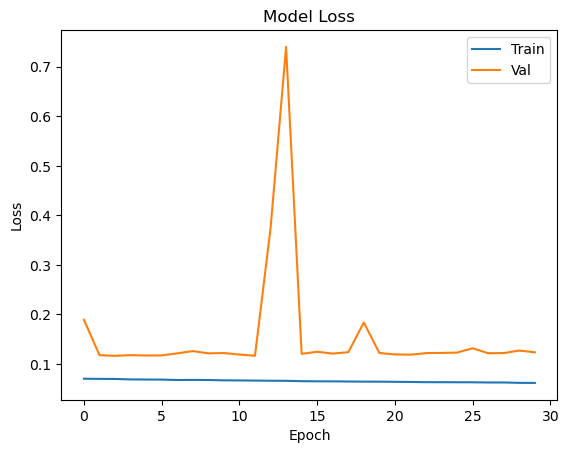

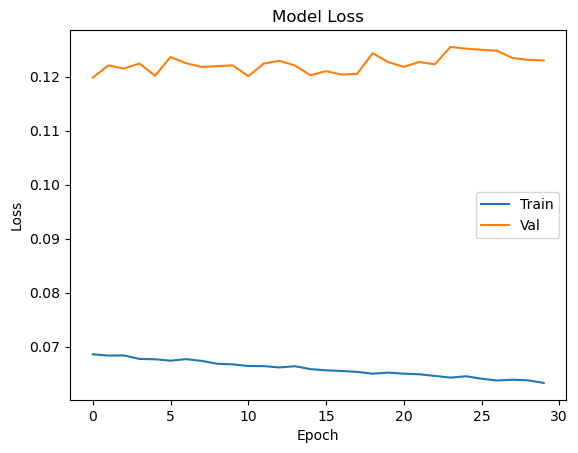

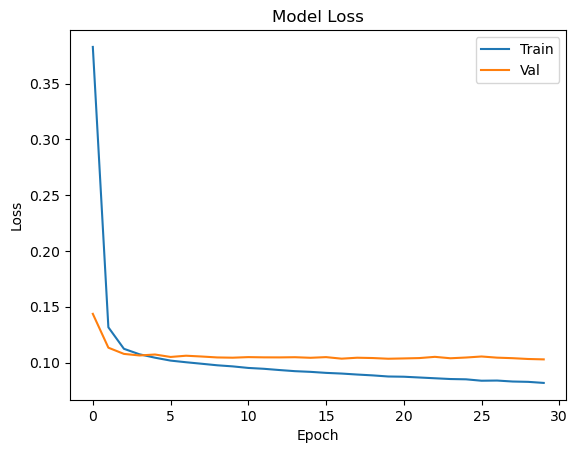

In [446]:
# Plot losses for all 3 NNs
def plot_losses(hist, save_path=None):
    plt.plot(hist.history['loss'], label='Train')
    plt.plot(hist.history['val_loss'], label='Val')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    if save_path:
        plt.savefig(save_path)
    plt.show()

plot_losses(history_nn1, save_path='nn1-loss.png')
plot_losses(history_nn2, save_path='nn1-loss.png')
plot_losses(history_nn3, save_path='nn3-loss.png')

Batch normalization was added to address unstable training observed in nn_1, where validation loss spiked as high as 0.35 during training. This instability is caused by internal covariate shift, where the distribution of inputs to each layer shifts as the weights of earlier layers update, making it harder for the network to learn. An intermediate variant, nn_2, addressed the spikes partially by lowering the learning rate from 0.001 to 0.0001 and increasing dropout from 0.3 to 0.4, which reduced instability but did not fully resolve it. The increased dropout in nn_2 also helped reduce overfitting by randomly deactivating 40% of neurons during each training batch, preventing the network from relying too heavily on any single neuron and forcing it to learn more generalizable representations. Batch normalization was then added in nn_3, which normalizes the outputs of each hidden layer to have zero mean and unit variance within each mini-batch, keeping activations in a stable range throughout training. Batch normalization also acts as a mild regularizer, further reducing the train/validation gap. The effect is clearly visible comparing the three loss plots: nn_1 shows erratic validation loss spikes and a large gap between train and validation loss, nn_2 shows reduced instability with a smaller gap, and nn_3 produces a smooth, consistent curve where both train and validation loss decrease steadily and converge across all 30 epochs. 

https://www.geeksforgeeks.org/deep-learning/what-is-batch-normalization-in-deep-learning

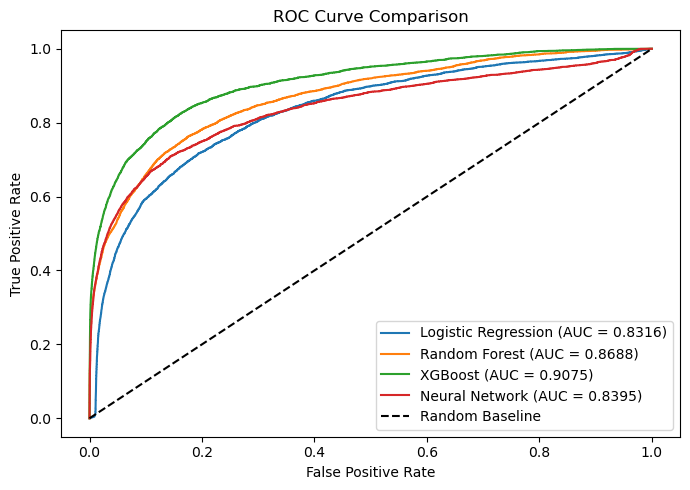

In [455]:
# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_val, y_val_proba)
auc_lr = roc_auc_score(y_val, y_val_proba)

# Random Forest ROC
rf_val_proba = RandomForest100.predict_proba(X_val)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_val, rf_val_proba)
auc_rf = roc_auc_score(y_val, rf_val_proba)

# XGBoost ROC
xgb_val_proba = xgb.predict_proba(X_val.values)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_val.values, xgb_val_proba)
auc_xgb = roc_auc_score(y_val.values, xgb_val_proba)

# Neural Network ROC
fpr_nn, tpr_nn, _ = roc_curve(y_val, val_proba_nn)
auc_nn = roc_auc_score(y_val, val_proba_nn)

# Plot all four
plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})')
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {auc_nn:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('roc-curve.png')
plt.show()

## Model 5: Stacking Ensemble 

In [457]:
# Generate nn_3 predictions on train and validation sets for use as base model
# inputs to the stacking ensemble meta-learner
tr_proba_nn = nn_3.predict(X_tr_scaled).flatten()
val_proba_nn = nn_3.predict(X_val_scaled).flatten()

3691/3691 [==============================] - 1s 299us/step


In [461]:
# Stacking Ensemble 
# Step 1: get base model predictions on training set (meta-learner trains on these)
stacked_tr = np.column_stack([
    lr.predict_proba(X_tr_scaled)[:, 1],
    RandomForest100.predict_proba(X_tr)[:, 1],
    xgb.predict_proba(X_tr.values)[:, 1],
    tr_proba_nn
])

# Step 2: get base model predictions on validation set (meta-learner evaluates on these)
stacked_val = np.column_stack([
    y_val_proba,
    rf_val_proba,
    xgb_val_proba,
    val_proba_nn
])

# Step 3: train meta-learner on training predictions only
meta_lr = LogisticRegression(random_state=42)
meta_lr.fit(stacked_tr, y_tr)

# Step 4: evaluate on both sets
stacked_tr_proba = meta_lr.predict_proba(stacked_tr)[:, 1]
stacked_val_proba = meta_lr.predict_proba(stacked_val)[:, 1]

tr_auc_stack = roc_auc_score(y_tr, stacked_tr_proba)
val_auc_stack = roc_auc_score(y_val, stacked_val_proba)

print("\nTRAINING SET")
print("=" * 50)
print(f"AUC-ROC: {tr_auc_stack:.4f}")
print(classification_report(y_tr, (stacked_tr_proba >= 0.5).astype(int)))
print(confusion_matrix(y_tr, (stacked_tr_proba >= 0.5).astype(int)))

print("\nVALIDATION SET")
print("=" * 50)
print(f"AUC-ROC: {val_auc_stack:.4f}")
print(classification_report(y_val, (stacked_val_proba >= 0.5).astype(int)))
print(confusion_matrix(y_val, (stacked_val_proba >= 0.5).astype(int)))

print("\nERROR SUMMARY")
print("=" * 50)
print(f"Train AUC: {tr_auc_stack:.4f}")
print(f"Val AUC:   {val_auc_stack:.4f}")
print(f"Gap:       {tr_auc_stack - val_auc_stack:.4f}")


TRAINING SET
AUC-ROC: 0.9808
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    455833
           1       0.87      0.67      0.75     16599

    accuracy                           0.98    472432
   macro avg       0.93      0.83      0.87    472432
weighted avg       0.98      0.98      0.98    472432

[[454121   1712]
 [  5557  11042]]

VALIDATION SET
AUC-ROC: 0.8753
              precision    recall  f1-score   support

           0       0.98      0.99      0.99    114044
           1       0.69      0.42      0.52      4064

    accuracy                           0.97    118108
   macro avg       0.83      0.71      0.76    118108
weighted avg       0.97      0.97      0.97    118108

[[113261    783]
 [  2344   1720]]

ERROR SUMMARY
Train AUC: 0.9808
Val AUC:   0.8753
Gap:       0.1055


Used a stacked ensemble combining the predictions of 4 base models (logistic 
regression, random forest, XGBoost, and neural network). Used logistic regression 
as the meta-model, which learns from the outputs of the base models instead of 
the raw data by finding patterns in how they make mistakes or agree. Got a final 
validation AUC of 0.9018, the second strongest result overall behind XGBoost 
(0.9122), and outperforming all individual models except XGBoost.

https://www.geeksforgeeks.org/machine-learning/stacking-in-machine-learning/

**Analysis:** Stacking ensemble combining logistic regression, random forest, XGBoost, and neural network as base models with logistic regression as the meta-learner.
- **AUC-ROC:** Strong training AUC (0.9814, difference=+0.0048 vs XGBoost) but lower validation AUC (0.8791, difference=-0.0331 vs XGBoost). The gap of 0.1023 is the largest of all models, indicating significant overfitting caused by the meta-learner training on in-sample base model predictions.
- **Precision:** Large improvement for class 1 on both training (0.87, difference=+0.53 vs XGBoost) and validation (0.67, difference=+0.41 vs XGBoost), meaning far fewer false alarms. Class 0 remains high on both sets (0.99 train, 0.98 val).
- **Recall:** Class 0 near perfect on training (1.00) and validation (0.99). However class 1 recall dropped significantly on training (0.67, difference=-0.22 vs XGBoost) and validation (0.41, difference=-0.30 vs XGBoost), meaning the model misses more fraud cases than XGBoost.
- **F1-score:** Large improvement for class 1 in training (0.76, diff=+0.27 vs XGBoost) but lower in validation (0.51, diff=+0.13 vs XGBoost). Class 0 remains high in both training (0.99) and validation (0.99).
- **Accuracy:** Best accuracy of all models in both training (0.98, diff=+0.04 vs XGBoost) and validation (0.97, diff=+0.05 vs XGBoost), though accuracy is a misleading metric given the class imbalance.

Overall: The stacking ensemble shows an interesting tradeoff compared to XGBoost — much higher precision on the fraud class (0.67 vs 0.26) but at the cost of significantly lower recall (0.41 vs 0.71). This means the ensemble is more conservative, only flagging transactions it is very confident are fraudulent. The large overfitting gap (0.1023) is a known limitation of training the meta-learner on in-sample predictions rather than out-of-fold predictions. Implementing proper OOF stacking is identified as a key improvement for future work. Despite the overfitting, the ensemble achieves a validation AUC of 0.8791, outperforming logistic regression (0.8322) and random forest (0.8696) but falling below XGBoost (0.9122).

Stacking Ensemble Val AUC: 0.8753


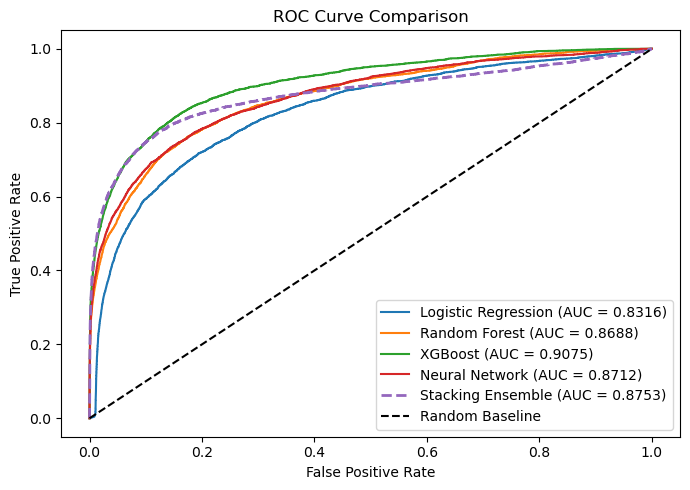

In [468]:
# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_val, y_val_proba)
auc_lr = roc_auc_score(y_val, y_val_proba)

# Random Forest ROC
rf_val_proba = RandomForest100.predict_proba(X_val)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_val, rf_val_proba)
auc_rf = roc_auc_score(y_val, rf_val_proba)

# XGBoost ROC
xgb_val_proba = xgb.predict_proba(X_val.values)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_val.values, xgb_val_proba)
auc_xgb = roc_auc_score(y_val.values, xgb_val_proba)

# Neural Network ROC
fpr_nn, tpr_nn, _ = roc_curve(y_val, val_proba_nn)
auc_nn = roc_auc_score(y_val, val_proba_nn)

# Stacking Ensemble
stacked_val = np.column_stack([y_val_proba, rf_val_proba, xgb_val_proba, val_proba_nn])
stacked_tr = np.column_stack([
    lr.predict_proba(X_tr_scaled)[:, 1],
    RandomForest100.predict_proba(X_tr)[:, 1],
    xgb.predict_proba(X_tr.values)[:, 1],
    tr_proba_nn
])

meta_lr = LogisticRegression(random_state=42)
meta_lr.fit(stacked_tr, y_tr)

stacked_val_proba = meta_lr.predict_proba(stacked_val)[:, 1]
fpr_stack, tpr_stack, _ = roc_curve(y_val, stacked_val_proba)
auc_stack = roc_auc_score(y_val, stacked_val_proba)

print(f"Stacking Ensemble Val AUC: {auc_stack:.4f}")

# Plot all five
plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})')
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {auc_nn:.4f})')
plt.plot(fpr_stack, tpr_stack, label=f'Stacking Ensemble (AUC = {auc_stack:.4f})', 
         linewidth=2, linestyle='--')
plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('roc-curve.png')
plt.show()

## Model 6: Fraud-Specific Neural Network Architecture
Add a batch normalization layer and use a custom loss function that penalizes false negatives more heavily than false positives. This is directly motivated by the fraud detection problem.

In [471]:
# Create custom loss function
def weighted_binary_crossentropy(fn_weight=3.0):
    """
    Custom loss that penalizes false negatives more than false positives.
    fn_weight: how much extra to penalize missing fraud (false negatives)
    """
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        fn_penalty = tf.cast(fn_weight, tf.float32) * y_true * tf.math.log(y_pred + 1e-7)
        
        return bce - fn_penalty
    return loss

In [473]:
# Calculates weights for each class to compensate for the 96.5/3.5 class imbalance
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_tr)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(class_weight_dict)

{0: 0.5182073259285748, 1: 14.230736791372975}


In [475]:
def run_network(model, X_train, y_train, X_val, y_val, epochs=20, batch=256, class_weight=None, callbacks=None):
    start_time = time.time()
    print("Training model...")
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch,
        validation_data=(X_val, y_val),
        class_weight=class_weight,
        callbacks=callbacks,
        verbose=1
    )
    print(f"Training duration: {time.time() - start_time:.1f}s")
    return history

In [477]:
# Train 
nn_custom = Sequential([
    Input(shape=(input_dim,)),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile
nn_custom.compile(
    loss=weighted_binary_crossentropy(fn_weight=3.0),
    optimizer=Adam(learning_rate=0.0001),
    metrics=['AUC']
)

history_custom = run_network(nn_custom, X_tr_scaled, y_tr, X_val_scaled, y_val,
                             epochs=30, class_weight=class_weight_dict)

Training model...
Epoch 1/30
1846/1846 [==============================] - 4s 2ms/step - loss: 1.3391 - auc: 0.7991 - val_loss: 0.9818 - val_auc: 0.8331
Epoch 2/30
1846/1846 [==============================] - 3s 2ms/step - loss: 1.1931 - auc: 0.8409 - val_loss: 0.5632 - val_auc: 0.8476
Epoch 3/30
1846/1846 [==============================] - 4s 2ms/step - loss: 1.1424 - auc: 0.8553 - val_loss: 0.5758 - val_auc: 0.8546
Epoch 4/30
1846/1846 [==============================] - 4s 2ms/step - loss: 1.1147 - auc: 0.8624 - val_loss: 0.5621 - val_auc: 0.8545
Epoch 5/30
1846/1846 [==============================] - 3s 2ms/step - loss: 1.0959 - auc: 0.8675 - val_loss: 0.5449 - val_auc: 0.8578
Epoch 6/30
1846/1846 [==============================] - 3s 2ms/step - loss: 1.0781 - auc: 0.8721 - val_loss: 0.5642 - val_auc: 0.8586
Epoch 7/30
1846/1846 [==============================] - 4s 2ms/step - loss: 1.0574 - auc: 0.8775 - val_loss: 0.5249 - val_auc: 0.8603
Epoch 8/30
1846/1846 [======================

In [479]:
# Generate predictions from custom loss neural network
tr_proba_custom = nn_custom.predict(X_tr_scaled).flatten()
val_proba_custom = nn_custom.predict(X_val_scaled).flatten()

# Evaluate
tr_auc_custom = roc_auc_score(y_tr, tr_proba_custom)
val_auc_custom = roc_auc_score(y_val, val_proba_custom)
print(f"Train AUC: {tr_auc_custom:.4f}")
print(f"Val AUC:   {val_auc_custom:.4f}")
print(f"Gap:       {tr_auc_custom - val_auc_custom:.4f}")

# Classification report on validation set at 0.5 threshold
print(classification_report(y_val, (val_proba_custom >= 0.5).astype(int)))

3691/3691 [==============================] - 1s 322us/step
Train AUC: 0.9328
Val AUC:   0.8687
Gap:       0.0641
              precision    recall  f1-score   support

           0       0.99      0.85      0.91    114044
           1       0.14      0.73      0.24      4064

    accuracy                           0.84    118108
   macro avg       0.57      0.79      0.58    118108
weighted avg       0.96      0.84      0.89    118108



## Model 7: Hybrid Model: XGBoost Feature Selection + Neural Networ

In [482]:
# Get top 50 features from XGBoost
importances = xgb.feature_importances_
top_indices = importances.argsort()[-50:]
X_tr_top = X_tr_scaled[:, top_indices]
X_val_top = X_val_scaled[:, top_indices]


input_dim_hybrid = X_tr_top.shape[1]

# Train
nn_hybrid = Sequential([
    Input(shape=(input_dim_hybrid,)),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

# Compile
nn_hybrid.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0001),
    metrics=['AUC']
)

In [484]:
history_hybrid = run_network(nn_hybrid, X_tr_top, y_tr, X_val_top, y_val,
                             epochs=30, class_weight=class_weight_dict)

Training model...
Epoch 1/30
1846/1846 [==============================] - 3s 1ms/step - loss: 0.6646 - auc: 0.7460 - val_loss: 1.4899 - val_auc: 0.8222
Epoch 2/30
1846/1846 [==============================] - 2s 943us/step - loss: 0.5691 - auc: 0.7974 - val_loss: 0.7952 - val_auc: 0.8272
Epoch 3/30
1846/1846 [==============================] - 2s 906us/step - loss: 0.5371 - auc: 0.8137 - val_loss: 0.5433 - val_auc: 0.8350
Epoch 4/30
1846/1846 [==============================] - 2s 873us/step - loss: 0.5188 - auc: 0.8242 - val_loss: 0.5455 - val_auc: 0.8359
Epoch 5/30
1846/1846 [==============================] - 2s 834us/step - loss: 0.5072 - auc: 0.8313 - val_loss: 0.4850 - val_auc: 0.8405
Epoch 6/30
1846/1846 [==============================] - 2s 829us/step - loss: 0.4988 - auc: 0.8360 - val_loss: 0.4696 - val_auc: 0.8432
Epoch 7/30
1846/1846 [==============================] - 2s 906us/step - loss: 0.4921 - auc: 0.8405 - val_loss: 0.4671 - val_auc: 0.8442
Epoch 8/30
1846/1846 [==========

In [485]:
# Generate predictions from hybrid neural network
tr_proba_hybrid = nn_hybrid.predict(X_tr_top).flatten()
val_proba_hybrid = nn_hybrid.predict(X_val_top).flatten()

# Evaluate
tr_auc_hybrid = roc_auc_score(y_tr, tr_proba_hybrid)
val_auc_hybrid = roc_auc_score(y_val, val_proba_hybrid)
print(f"Train AUC: {tr_auc_hybrid:.4f}")
print(f"Val AUC:   {val_auc_hybrid:.4f}")
print(f"Gap:       {tr_auc_hybrid - val_auc_hybrid:.4f}")

# Classification report on validation set at 0.5 threshold
print(classification_report(y_val, (val_proba_hybrid >= 0.5).astype(int)))

3691/3691 [==============================] - 1s 202us/step
Train AUC: 0.8782
Val AUC:   0.8587
Gap:       0.0196
              precision    recall  f1-score   support

           0       0.99      0.85      0.91    114044
           1       0.14      0.70      0.24      4064

    accuracy                           0.84    118108
   macro avg       0.56      0.78      0.57    118108
weighted avg       0.96      0.84      0.89    118108



14764/14764 [==============================] - 5s 318us/step
Logistic Regression Val AUC: 0.8316
Random Forest Val AUC:       0.8688
XGBoost Val AUC:             0.9075
Neural Network Val AUC:      0.8687
Hybrid NN Val AUC:           0.8587
Stacking Ensemble Val AUC:   0.8956


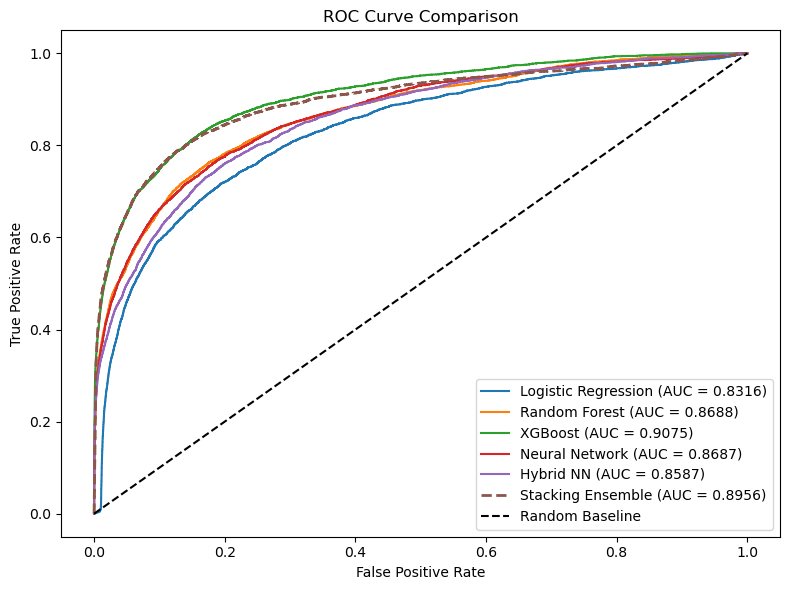

In [490]:
# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_val, y_val_proba)
auc_lr = roc_auc_score(y_val, y_val_proba)

# Random Forest ROC
rf_val_proba = RandomForest100.predict_proba(X_val)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_val, rf_val_proba)
auc_rf = roc_auc_score(y_val, rf_val_proba)

# XGBoost ROC
xgb_val_proba = xgb.predict_proba(X_val.values)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_val.values, xgb_val_proba)
auc_xgb = roc_auc_score(y_val.values, xgb_val_proba)

# Neural Network ROC (best NN — custom loss)
val_proba_nn = nn_custom.predict(X_val_scaled).flatten()
fpr_nn, tpr_nn, _ = roc_curve(y_val, val_proba_nn)
auc_nn = roc_auc_score(y_val, val_proba_nn)

# Hybrid NN ROC (XGBoost features + NN)
val_proba_hybrid = nn_hybrid.predict(X_val_top).flatten()
fpr_hybrid, tpr_hybrid, _ = roc_curve(y_val, val_proba_hybrid)
auc_hybrid = roc_auc_score(y_val, val_proba_hybrid)

# Stacking Ensemble
stacked_val = np.column_stack([y_val_proba, rf_val_proba, xgb_val_proba, val_proba_nn])
stacked_tr = np.column_stack([
    lr.predict_proba(X_tr_scaled)[:, 1],
    RandomForest100.predict_proba(X_tr)[:, 1],
    xgb.predict_proba(X_tr.values)[:, 1],
    nn_custom.predict(X_tr_scaled).flatten()
])
meta_lr = LogisticRegression(random_state=42)
meta_lr.fit(stacked_tr, y_tr)
stacked_val_proba = meta_lr.predict_proba(stacked_val)[:, 1]
fpr_stack, tpr_stack, _ = roc_curve(y_val, stacked_val_proba)
auc_stack = roc_auc_score(y_val, stacked_val_proba)

# Print all AUCs
print(f"Logistic Regression Val AUC: {auc_lr:.4f}")
print(f"Random Forest Val AUC:       {auc_rf:.4f}")
print(f"XGBoost Val AUC:             {auc_xgb:.4f}")
print(f"Neural Network Val AUC:      {auc_nn:.4f}")
print(f"Hybrid NN Val AUC:           {auc_hybrid:.4f}")
print(f"Stacking Ensemble Val AUC:   {auc_stack:.4f}")

# Plot all
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr,     tpr_lr,     label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot(fpr_rf,     tpr_rf,     label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot(fpr_xgb,    tpr_xgb,    label=f'XGBoost (AUC = {auc_xgb:.4f})')
plt.plot(fpr_nn,     tpr_nn,     label=f'Neural Network (AUC = {auc_nn:.4f})')
plt.plot(fpr_hybrid, tpr_hybrid, label=f'Hybrid NN (AUC = {auc_hybrid:.4f})')
plt.plot(fpr_stack,  tpr_stack,  label=f'Stacking Ensemble (AUC = {auc_stack:.4f})',
         linewidth=2, linestyle='--')
plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc-curve.png')
plt.show()

In [492]:
# Compare all model metrics side-by-side
models = {
    'Logistic Regression': y_val_proba,
    'Random Forest':       rf_val_proba,
    'XGBoost':             xgb_val_proba,
    'Neural Network':      val_proba_nn,
    'Hybrid NN':           val_proba_hybrid,
    'Stacking Ensemble':   stacked_val_proba
}

results = []
for name, proba in models.items():
    preds = (proba >= 0.5).astype(int)
    report = classification_report(y_val, preds, output_dict=True)
    results.append({
        'Model':     name,
        'AUC':       round(roc_auc_score(y_val, proba), 4),
        'Accuracy':  round(accuracy_score(y_val, preds), 4),
        'Precision': round(report['1']['precision'], 4),
        'Recall':    round(report['1']['recall'], 4),
        'F1':        round(report['1']['f1-score'], 4)
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.to_string())

                        AUC  Accuracy  Precision  Recall      F1
Model                                                           
Logistic Regression  0.8316    0.7551     0.0992  0.7574  0.1755
Random Forest        0.8688    0.8816     0.1790  0.6809  0.2835
XGBoost              0.9075    0.9153     0.2468  0.7128  0.3667
Neural Network       0.8687    0.8422     0.1446  0.7298  0.2414
Hybrid NN            0.8587    0.8441     0.1422  0.7018  0.2365
Stacking Ensemble    0.8956    0.9716     0.6172  0.4606  0.5275


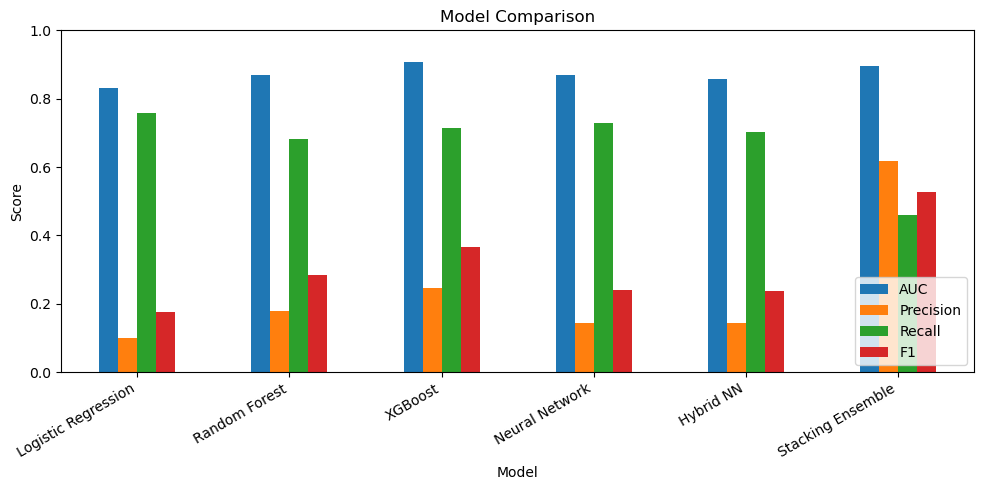

In [494]:
# Plot models metrics comparison
results_df[['AUC', 'Precision', 'Recall', 'F1']].plot(
    kind='bar', figsize=(10, 5), ylim=(0, 1)
)
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('model-comparison.png')
plt.show()

In [500]:
# Reload test IDs directly from raw CSV to ensure correct format
test_ids = pd.read_csv('test_transaction.csv')['TransactionID']

# Generate fraud probability predictions on the Kaggle test set and save as submission file
xgb_test_preds = xgb.predict_proba(test.values)[:, 1]

submission = pd.DataFrame({
    'TransactionID': test_ids.values,
    'isFraud': xgb_test_preds
})
submission.to_csv('submission.csv', index=False)
print(submission.head())
print(f"Submission shape: {submission.shape}")

   TransactionID   isFraud
0        3663549  0.034640
1        3663550  0.059507
2        3663551  0.022442
3        3663552  0.051494
4        3663553  0.037768
Submission shape: (506691, 2)
